<a href="https://colab.research.google.com/github/Hhasan04/MLHomeWorks/blob/main/HomeWrokML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 0, Loss: 0.6931471805599435
Epoch 100, Loss: 0.5629888857021527
Epoch 200, Loss: 0.5170278917725266
Epoch 300, Loss: 0.4772244253382146
Epoch 400, Loss: 0.4426589862293846
Epoch 500, Loss: 0.41252306793787696
Epoch 600, Loss: 0.3861249015211718
Epoch 700, Loss: 0.36288249315876203
Epoch 800, Loss: 0.3423109014716335
Epoch 900, Loss: 0.32400793252151033
Epoch 1000, Loss: 0.30764043742998304
Epoch 1100, Loss: 0.29293216673730726
Epoch 1200, Loss: 0.279653455970413
Epoch 1300, Loss: 0.2676126809260877
Epoch 1400, Loss: 0.2566492797596575
Epoch 1500, Loss: 0.24662809902515373
Epoch 1600, Loss: 0.23743482904416222
Epoch 1700, Loss: 0.22897232181586738
Epoch 1800, Loss: 0.2211576177701915
Epoch 1900, Loss: 0.2139195393987086
Epoch 2000, Loss: 0.20719673757225535
Epoch 2100, Loss: 0.20093609952942887
Epoch 2200, Loss: 0.1950914463376805
Epoch 2300, Loss: 0.18962246266445748
Epoch 2400, Loss: 0.1844938135982277
Epoch 2500, Loss: 0.17967441263370662
Epoch 2600, Loss: 0.17513681230272263
E

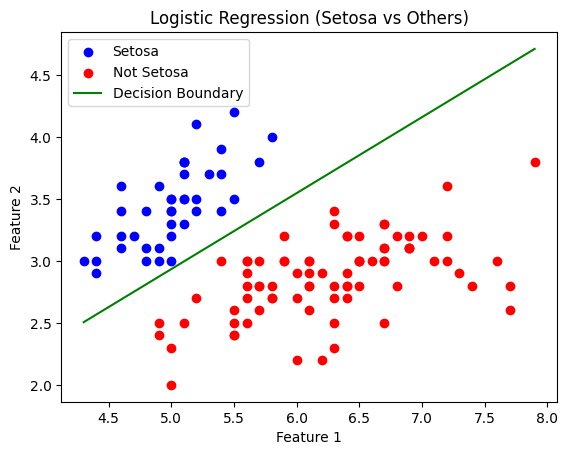

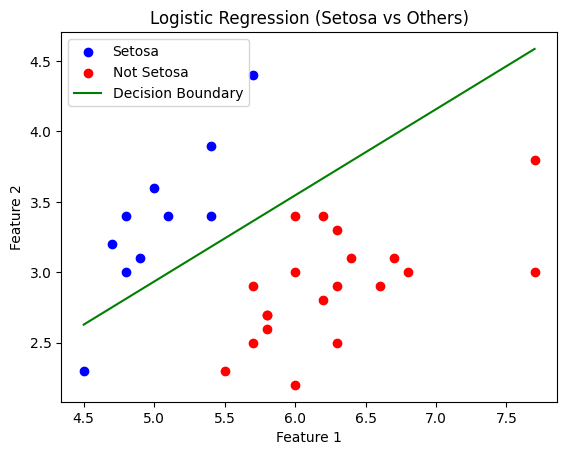

In [ ]:
# Machine learning Home Work
# Done by Hasan Abo Snena 221056

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

def sigmoid(z):
  return 1/(1 + np.exp(-z))

def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    W = np.zeros(n + 1) # thetas
    X_b = np.c_[np.ones((m, 1)), X] # x0 is set to 1 and concatinated with x

    for epoch in range(epochs):
        z = X_b.dot(W)
        y_pred = sigmoid(z) # new line
        error = y_pred - y

        gradient = (1/m) * X_b.T.dot(error) # .T is transport .dot is dot product
        W -= learning_rate * gradient

        if epoch % 100 == 0:
        # loss = (1/(2*m)) * np.sum(error**2) <-- old loss calculation
          loss = -(1/m) * np.sum(y*np.log(y_pred + 1e-15) + (1 - y)*np.log(1 - y_pred + 1e-15)) # new loss calculation
          print(f"Epoch {epoch}, Loss: {loss}")

    return W

if __name__ == "__main__":
    # 1. Load the iris dataset
    iris = load_iris()
    X = iris.data[:, [0, 1]]
    y = (iris.target == 0).astype(int)

    # 2. Split the data (90% training, 10% testing)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=37, stratify=y
    )

    # Train model
    weights = gradient_descent(X_train, y_train, learning_rate=0.01, epochs=5000)


    # Evaluate model on test set
    X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]
    y_pred_prob = sigmoid(X_test_b.dot(weights))
    y_pred = (y_pred_prob >= 0.5).astype(int)

    accuracy = np.mean(y_pred == y_test)
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

    # Visualization
    plt.scatter(X_train[y_train==1][:, 0], X_train[y_train==1][:, 1], color='blue', label='Setosa')
    plt.scatter(X_train[y_train==0][:, 0], X_train[y_train==0][:, 1], color='red', label='Not Setosa')

    x1_vals = np.linspace(min(X_train[:,0]), max(X_train[:,0]), 100)
    x2_vals = -(weights[0] + weights[1]*x1_vals)/weights[2]
    plt.plot(x1_vals, x2_vals, color='green', label='Decision Boundary')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title('Logistic Regression (Setosa vs Others)')
    plt.show()

    plt.scatter(X_test[y_test==1][:, 0], X_test[y_test==1][:, 1], color='blue', label='Setosa')
    plt.scatter(X_test[y_test==0][:, 0], X_test[y_test==0][:, 1], color='red', label='Not Setosa')

    x1_vals = np.linspace(min(X_test[:,0]), max(X_test[:,0]), 100)
    x2_vals = -(weights[0] + weights[1]*x1_vals)/weights[2]
    plt.plot(x1_vals, x2_vals, color='green', label='Decision Boundary')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title('Logistic Regression (Setosa vs Others)')
    plt.show()
